# Gradient Descent (Lineal Regresion)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import clear_output
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

(400, 1) (100, 1)


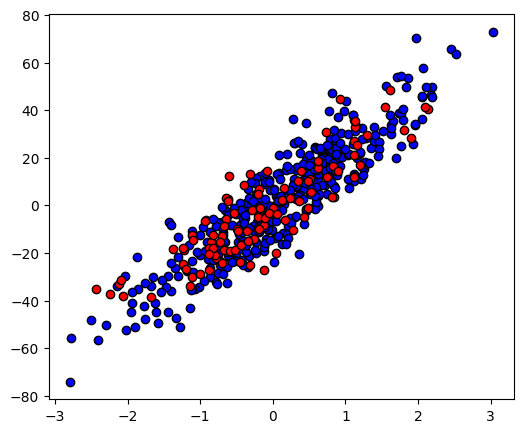

In [9]:
X, y = make_regression(n_samples = 500, n_features = 1 , noise = 10, random_state = 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

_, ax = plt.subplots(1,1, figsize=(6,5))
ax.scatter( X_train , y_train , edgecolors= 'k',  c='b')
ax.scatter( X_test , y_test , edgecolors= 'k',  c='r')
print (X_train.shape, X_test.shape)

In [10]:
def mse (y_true, y_pred):
  return np.square(y_true - y_pred).mean()

Useful definitions:

$\Large{y = mx_i + b }$ \\

$J = \Large{\frac{1}{n} \sum^{n}_{i=1} (y_i - mx_i + b)^2 }$

In [29]:
# Parameter definition
# Calcular el val de gradiente cuando mi funct no decrementa ni der ni izq =>
# quiere decir que mi gradiante es 0 ahi decimos que encontramos un valor optimo
epochs = 100 #epocas no es lo mismo de iteracion porque entrenamos solo una iteracion
learning_rate = 0.1
stop_criteria = 1e-3 # creterio de parada menor al stop cretiria convergencia

# Initial values
m = 5
b = 2

# Additional options
display_step = 5
steps = len(X_train)
loss = [] # error promedio por epoca se va a un lista el valor y se visualiza al final

# Optimization process
for epoch in range(epochs):
    # Gradient initialization
    #reinicializar los gradient siempre
    m_gradient  = 0
    b_gradient  = 0
    epoch_error = 0 #error acumulado apra todas la muestras

    # Compute error and gradients
    for i in range(0, steps ):
        #
        prediction = m * X_train[i] + b
        error = mse(y_train[i], prediction)

        # Compute the gradients
        #calculo de los dos gradients
        m_gradient -= (2/steps) * (y_train[i] - prediction) * X_train[i]
        b_gradient -= (2/steps) * (y_train[i] - prediction)
        epoch_error += error

    # Update params
    m = m - (learning_rate * m_gradient )
    b = b - (learning_rate * b_gradient )

    # Save average error as loss
    loss.append(epoch_error / steps)

    # Show everything every display_step epochs
    if epoch % display_step == 0:
        plt.scatter(X_train, y_train) #traza la linea de X y y
        # line between min-max--points
        pred_x = [min(X_train), max(X_train)] #valor min de x multiplicado el valor actual de b
        pred_y = [m * min(X_train) + b, m * max(X_train) + b ]
        plt.title('Epoch: {0}, MSE: {1}'.format(epoch, epoch_error / steps)) #mse seria el loss
        plt.plot(pred_x, pred_y, "r")
        plt.show()
        plt.pause(1) # se detiene un segundo
        clear_output(wait=False)

    # Convergence condition
    #si el gradiente es mas pequeno
    if max(abs(learning_rate * m_gradient), abs(learning_rate * b_gradient)) < stop_criteria:
        break

# Impresión de los resultados
print("Computed values are: ", m, b)
print("Finished in ", epoch, " epochs ")

Computed values are:  [22.16980993] [-0.04579254]
Finished in  39  epochs 


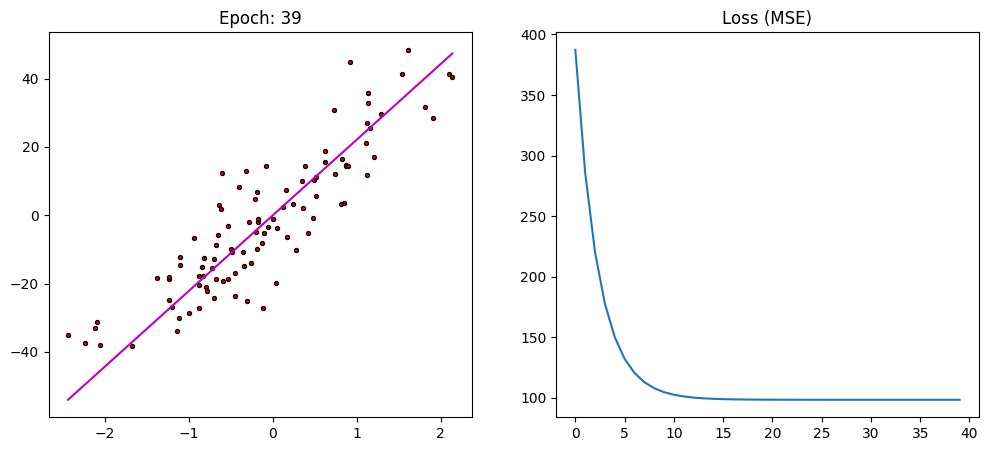

In [30]:
pred_x = [min(X_test), max(X_test)]
pred_y = [m * min(X_test) + b , m * max(X_test) + b]


_, axes = plt.subplots(1,2, figsize=(12,5))
axes[0].scatter( X_test , y_test , c='r', edgecolors = 'k', s=8)
axes[0].set_title('Epoch: {0}'.format(epoch))
axes[0].plot( pred_x , pred_y , "m")

# plotting the loss
axes[1].plot(range(0, len(loss)), loss), axes[1].set_title("Loss (MSE)")
plt.show()

## Putting everything together

In [46]:
class our_linear_model():
  def __init__(self, m = 1, b = 1, learning_rate = 0.1, stop_criteria = 1e-3):
    #self: atts que pertenecen a una clase y los que no pertenecen quiero declarar los atts dentro de ella misma
    self.m_ = m
    self.b_ = b
    self.learning_rate = learning_rate
    self.stop_criteria = stop_criteria
    self.loss = []

  def predict (self, x):
    return self.m_ * x + self.b_

  def mse (self, y_true, y_pred):
    return np.square(y_true - y_pred).mean()
  #esta funcion se encarga de actualizar los valores del gradiente directamente dentro de una funcion
  def gradient_step (self, m_gradient, b_gradient):
    #actualizar valores de m y b son los atts de la clase
    self.m_ -= (self.learning_rate * m_gradient )
    self.b_ -= (self.learning_rate * b_gradient )
    return None

  def fit (self, X, y, epochs = 100, display_step = 5):
    #
    steps = len(X)
    for epoch in range(epochs) :
      # Gradient initialization
      m_gradient, b_gradient, epoch_error = 0, 0, 0

      # Compute error and gradients
      for i in range(0, steps ):
          # calculo de predicciones y error
          prediction = self.predict(X[i])
          error = self.mse(y[i], prediction)

          # Compute the gradients
          m_gradient -= (2/steps) * (y[i] - prediction) * X[i]
          b_gradient -= (2/steps) * (y[i] - prediction)
          epoch_error += error

      # Update params m y b
      self.gradient_step(m_gradient, b_gradient)

      # Save average error as loss
      self.loss.append(epoch_error / steps)

      # Show everything every display_step epochs
      if epoch % display_step == 0:
          plt.scatter(X, y)
          pred_x = [min(X), max(X)]
          pred_y = [ self.predict(min(X)) , self.predict(max(X)) ]
          plt.title('Epoch: {0}, MSE: {1}'.format(epoch, epoch_error / error))
          plt.plot( pred_x , pred_y , "r")
          plt.show()
          plt.pause(1)
          clear_output(wait=False)

      # Convergence condition
      if max(abs(self.learning_rate * m_gradient), abs(self.learning_rate * b_gradient)) < self.stop_criteria:
          break


In [47]:
model = our_linear_model()
#entrenar el modelo - este modelo sigue la misma estructura de SKLEARN
model.fit (X_train, y_train)

# Print params
print("Computed values are: ", model.m_, model.b_)

Computed values are:  [22.16997028] [-0.04597807]


(100, 1)


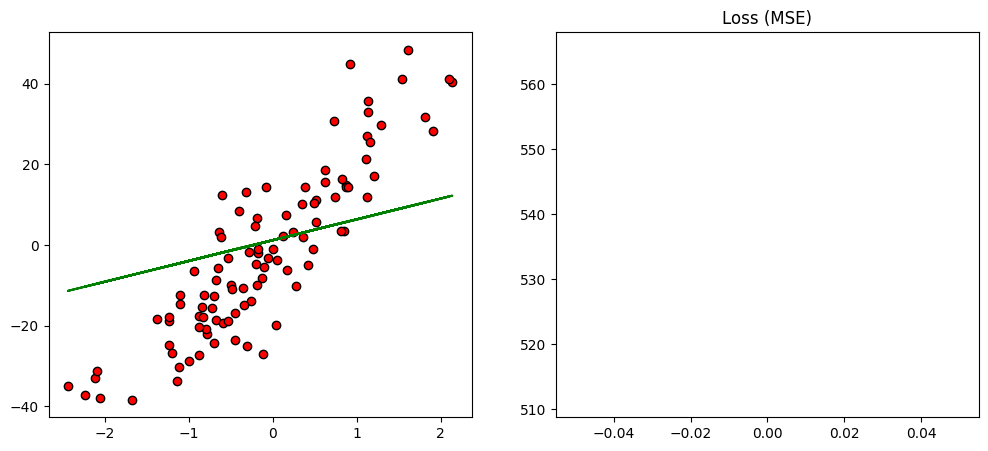

In [42]:
pred_x = [min(X_test), max(X_test)]
pred_y = [model.predict(min(X_test)), model.predict(max(X_test))]

predictions = model.predict(X_test)
print(predictions.shape)

_, axes = plt.subplots(1,2, figsize=(12,5))
axes[0].scatter( X_test , y_test , c='r', edgecolors = 'k')
#axes[0].plot( pred_x , pred_y , "g")
axes[0].plot(X_test, predictions, 'g')

axes[1].plot(range(0, len(model.loss)), model.loss)
axes[1].set_title("Loss (MSE)")
plt.show()